## 4. Exploratory Data Analysis

The EDA is developed as follows:
1. Descriptive statistics
2. Univariate analysis (distribution shape)
3. Temporal behavior - Time series analysis
4. Relationships analysis

In [1]:
# import libraries
import pandas as pd
from pathlib import Path
import warnings

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

In [2]:
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000
...,...,...,...,...,...,...,...,...,...,...,...,...
43809,2025-12-31 19:00:00,121.00000,0.60,3.75,0.0,3.419,22.65,2.33,29.33,0.227753,37002.25000,36421.74925
43810,2025-12-31 20:00:00,113.96499,0.60,2.82,0.0,3.145,21.33,2.08,26.83,0.204994,34212.50000,32732.99975
43811,2025-12-31 21:00:00,111.20000,0.60,2.11,0.0,2.691,20.11,1.67,24.49,0.178849,31110.24950,29597.99925
43812,2025-12-31 22:00:00,113.56500,0.60,1.78,0.0,2.427,18.65,1.36,22.39,0.167039,29077.25000,27451.50025


### 4.1. Descriptive Statistics

Descriptive statistics includes measures of central tendency, dispersion and distribution shape through the five years time span.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 43814 entries, 0 to 43813
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               43814 non-null  str    
 1   Prices             43814 non-null  float64
 2   Geothermal         43814 non-null  float64
 3   Hydro              43814 non-null  float64
 4   Photovoltaic       43814 non-null  float64
 5   Self-consumption   43814 non-null  float64
 6   Thermal            43814 non-null  float64
 7   Wind               43814 non-null  float64
 8   TOT Generation     43814 non-null  float64
 9   Renewables weight  43814 non-null  float64
 10  Total Load         43814 non-null  float64
 11  Load forecasted    43814 non-null  float64
dtypes: float64(11), str(1)
memory usage: 4.0 MB


In [4]:
# fix Date datatype
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data = data.dropna(subset=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

In [5]:
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000
...,...,...,...,...,...,...,...,...,...,...,...,...
43809,2025-12-31 19:00:00,121.00000,0.60,3.75,0.0,3.419,22.65,2.33,29.33,0.227753,37002.25000,36421.74925
43810,2025-12-31 20:00:00,113.96499,0.60,2.82,0.0,3.145,21.33,2.08,26.83,0.204994,34212.50000,32732.99975
43811,2025-12-31 21:00:00,111.20000,0.60,2.11,0.0,2.691,20.11,1.67,24.49,0.178849,31110.24950,29597.99925
43812,2025-12-31 22:00:00,113.56500,0.60,1.78,0.0,2.427,18.65,1.36,22.39,0.167039,29077.25000,27451.50025


In [6]:
data.describe()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
count,43814,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000,43814.000000
mean,2023-07-03 00:01:26.355959,156.204855,0.612284,4.766046,2.881881,3.622746,16.253147,2.456081,26.969438,0.397939,35676.336257,35873.450102
min,2021-01-01 00:00:00,0.000000,0.470000,0.610000,-0.010000,0.028000,3.990000,0.020000,11.110000,0.080460,17237.750000,17504.249500
25%,2022-04-02 13:15:00,98.520173,0.600000,2.740000,0.000000,2.470000,11.540000,1.010000,21.110000,0.285630,28627.062000,28864.812562
50%,2023-07-03 00:30:00,121.000000,0.610000,4.380000,0.090000,3.441000,15.710000,1.980000,26.660000,0.379409,35120.625500,35238.874500
75%,2024-10-01 11:45:00,179.343760,0.630000,6.457500,5.360000,4.564000,20.540000,3.570000,32.460000,0.492490,42471.687375,42666.499750
max,2025-12-31 23:00:00,870.000000,0.660000,14.470000,18.220000,9.240000,35.500000,8.790000,48.430000,0.849329,58528.250000,59726.499750
std,NaN,104.714617,0.021461,2.468278,4.102228,1.458013,6.063880,1.792900,7.114391,0.150404,8205.094413,8185.948293


From the descriptive statistics, it is evident that average electricity prices in Italy are relatively high. This is consistent with the fact that the Italian energy market is strongly influenced by natural gas prices, which still represent the dominant energy source, as also shown by the Thermal column, which reports the highest average electricity generation among all sources.  
This structure has been further affected by the Russian invasion of Ukraine and the subsequent disruption of Russian natural gas flows to Italy. As a result, both natural gas prices and market expectations (as reflected by the TTF index) increased significantly, contributing to higher electricity prices.

The actual Load and the forecasted Load display similar patterns across key descriptive statistics, suggesting a good overall alignment between observed and predicted energy consumption levels, although a more detailed error analysis would be required to fully assess predictive performance.

In [7]:
cols = ['Prices', 'Total Load', 'TOT Generation']

summary = []

for col in cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    std = data[col].std()
    mean = data[col].mean()

    summary.append({
        'variable': col,
        'mean': data[col].mean(),
        'median': data[col].median(),
        'min': data[col].min(),
        'max': data[col].max(),
        'Q1': q1,
        'Q3': q3,
        'std': std,
        'variance': data[col].var(),
        'range': data[col].max() - data[col].min(),
        'IQR': iqr,
        'RSD': std / mean
    })

summary_df = pd.DataFrame(summary)
summary_df

,variable,mean,median,min,max,Q1,Q3,std,variance,range,IQR,RSD
0,Prices,156.204855,121.0000,0.00,870.00,98.520173,179.343760,104.714617,1.096515e+04,870.00,80.823588,0.670367
1,Total Load,35676.336257,35120.6255,17237.75,58528.25,28627.062000,42471.687375,8205.094413,6.732357e+07,41290.50,13844.625375,0.229987
2,TOT Generation,26.969438,26.6600,11.11,48.43,21.110000,32.460000,7.114391,5.061455e+01,37.32,11.350000,0.263795


As indicated by the Relative Standard Deviation (RSD), defined as the standard deviation relative to the mean, load appears to be the most stable variable over time (22% variability relative to its mean), while prices and generation exhibit higher variability, at 67% and 80% respectively.

Electricity prices have shown notable instability, particularly since the beginning of the Russia–Ukraine war. However, generation displays even higher variability, which is consistent with the structure of the national energy mix. Renewable energy sources, mainly solar and wind, are gradually increasing their share and are inherently subject to weather-related fluctuations.

This suggests that variability in the system is driven more by supply-side dynamics than by demand or price formation alone.

### 4.2. Univariate analysis

In [8]:
dist_summary = []

for col in cols:
    skewness = data[col].skew()
    kurtosis = data[col].kurt()

    dist_summary.append({
        'variable': col,
        'skewness': skewness,
        'kurtosis': kurtosis,
    })

dist_summary_df = pd.DataFrame(dist_summary)
dist_summary_df

,variable,skewness,kurtosis
0,Prices,2.293087,6.506839
1,Total Load,0.137342,-0.986521
2,TOT Generation,0.185583,-0.822484


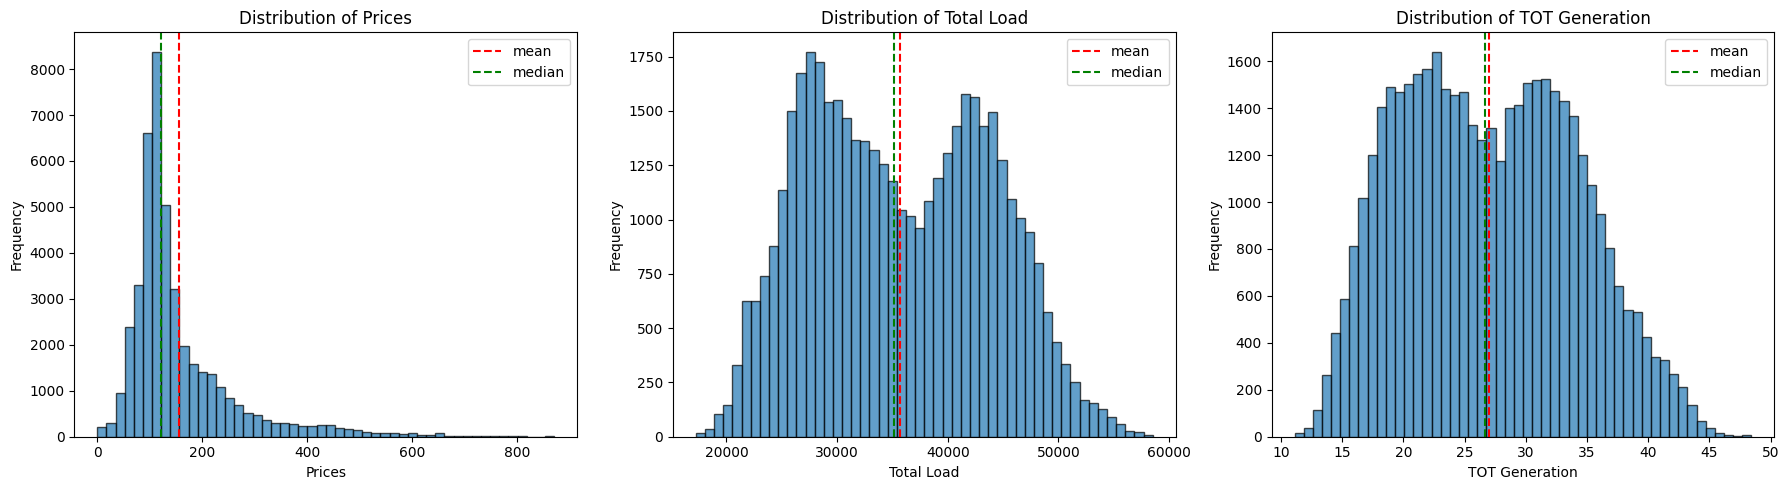

In [9]:
import matplotlib.pyplot as plt

# columns title
cols = ['Prices', 'Total Load', 'TOT Generation']

#create plot
fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for i, col in enumerate(cols):
    axes[i].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(data[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', label='median')
    axes[i].legend()

plt.tight_layout()
plt.show()

From the previous results, we can confidently say that distribution is highly asymetric with extreme events that suggest rare but intense prices spikes market.  
As a matter of fact, from the distribution graphs, it is obvious to exclude Normal distribution, as none of the three main measures is bell-shaped distributed.

In more datails:
* Prices' skewness at 2.29 and kurtosis at 6.5 confirm a shock-driven market as it is asymetric with intense spikes.
* Load is almost symetric, but has negative kurtosis, indicating a stable variable.
* Generation is characterized by a pretty high skew (1.8) indicating a structural asymetry which is consistent with the introduction of renewables.

### 4.3. Time series analysis

In this section, since the project aim to analyze the relationship between Prices, Load and Generation, time sereis evolution of those variables are displayed during the five-years time span.

#### 4.3.1. Raw time series

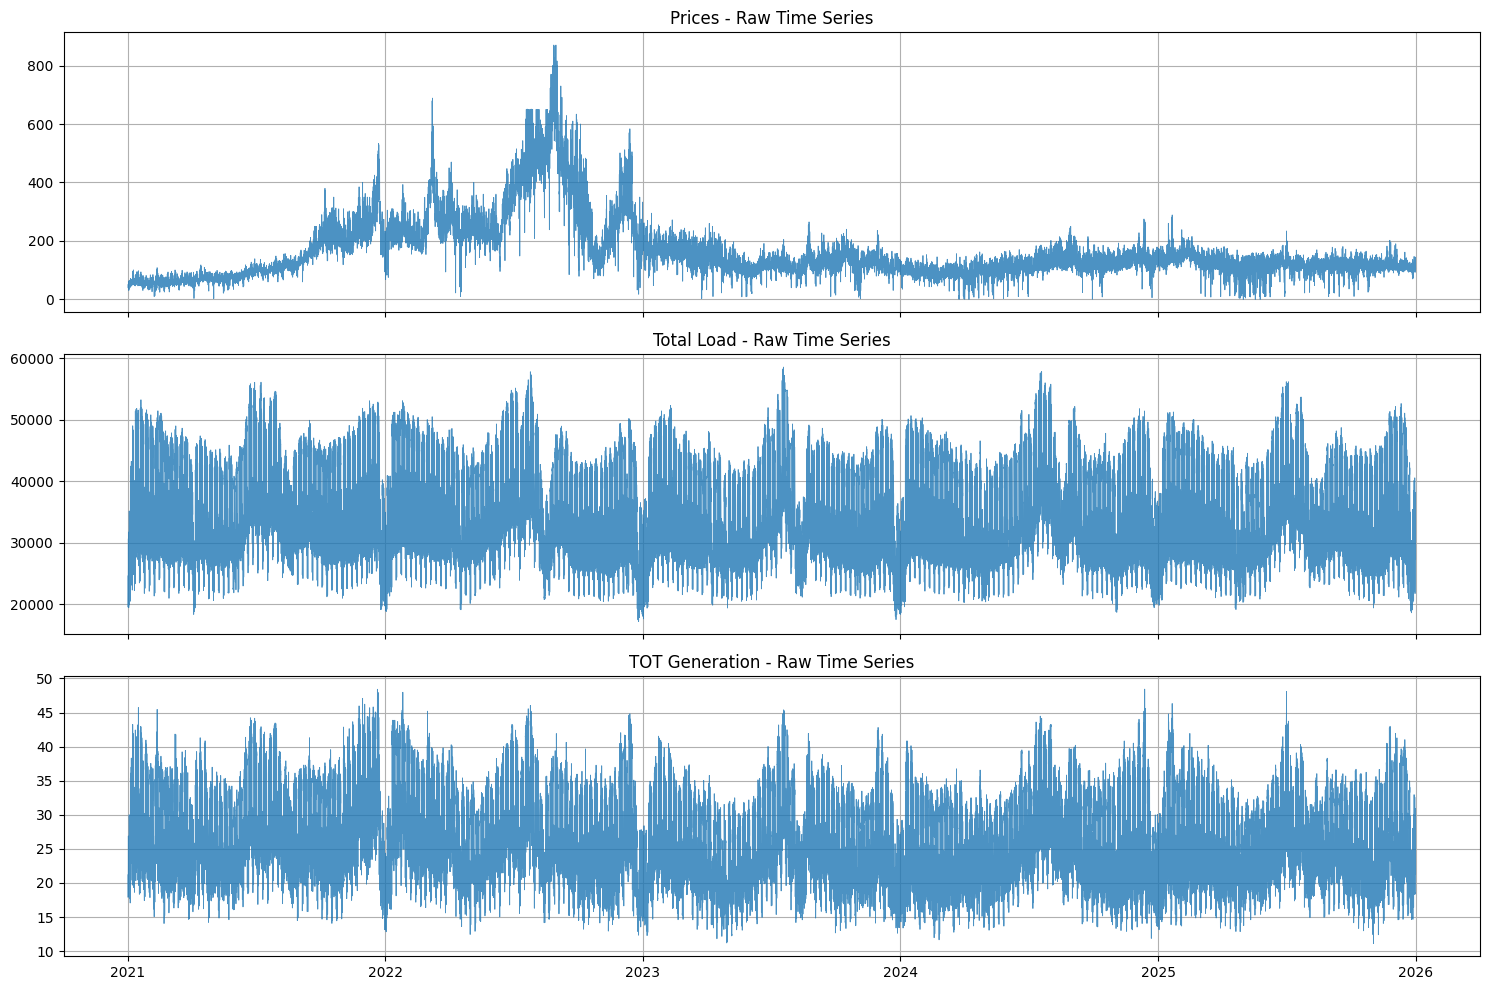

In [10]:
# import library
import matplotlib.pyplot as plt

# columns name
cols = ['Prices', 'Total Load', 'TOT Generation']

# plot graph
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], linewidth=0.6, alpha=0.8)
    ax[i].set_title(f'{col} - Raw Time Series')
    ax[i].grid(True)

plt.tight_layout()
plt.show()

#### 4.3.2. Rolling mean

For excluding the noise from the hourly observations and avoiding high copmutational effotrs, a rolling mean on the previous 24 hours is calculated and displayed.

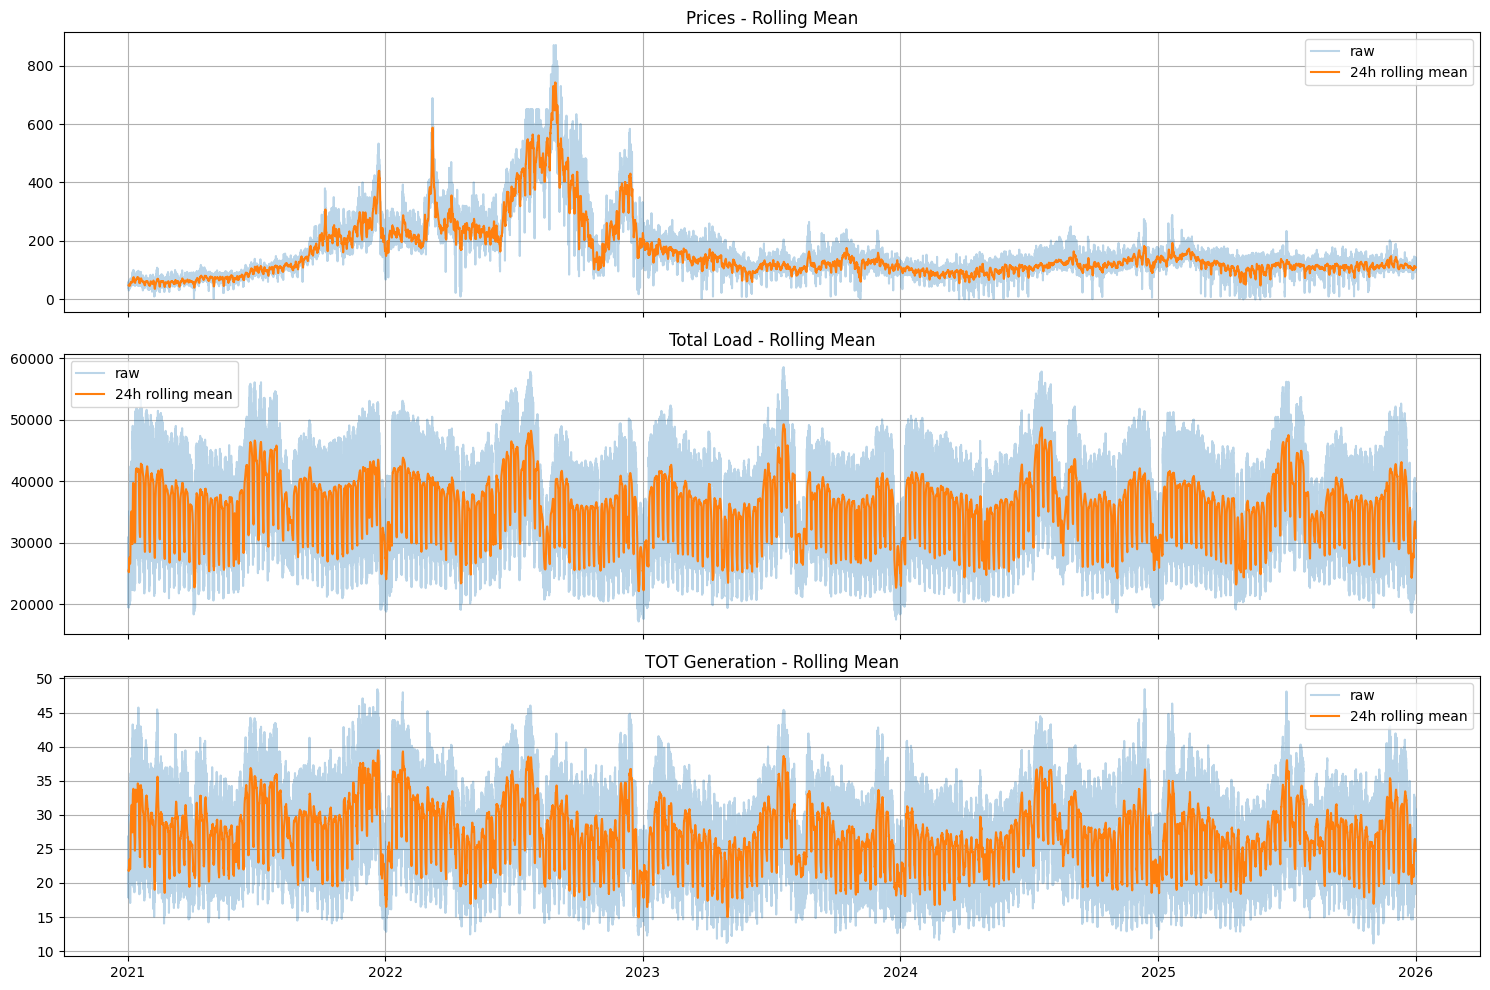

In [11]:
# define rolling window
window = 24  # 24h rolling window (1 day)

fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], alpha=0.3, label='raw')
    ax[i].plot(data['Date'], data[col].rolling(window).mean(), label='24h rolling mean')
    ax[i].set_title(f'{col} - Rolling Mean')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

It is evident from the first graph of the rolling average **Prices** from 2021 to 2026 that, from the end of 2021 to the end of 2022, the Italian power price registered an unexpected and more growing increase, with a peak verified between Q3 and Q4 of 2022.  
Russia-Ukraine war effects on highly gas dependent energy markets, such as the Italian one, are well displayed in the graph, as Russian gas imports stops were executed, initializing European energy crisis.

Yearly Italian **Load** shows a dual-season pattern, typical of temperate-climate electricity systems, since in winter heating are needed and diffused while in summer cooling systems are needed.  
It is noticeable how in spring and autumn months there is less demand of energy, while a particular New-Years-Eve effect is observable, characterized by a yearly minimum load of energy. This could be related to Christmas, New Year's Eve and Epiphany holidays, in which often Italian tend to organize vacations abroad, while all commercial buildings are closed.

The **Generation** pattern seems to follow an yearly cycle, similar to the Load one, even though the structural break observed in 2025 suggests a possible change in data definition, system boundary, or installed capacity and requires validation before economic interpretation.

#### 4.3.3. Volatility Analysis

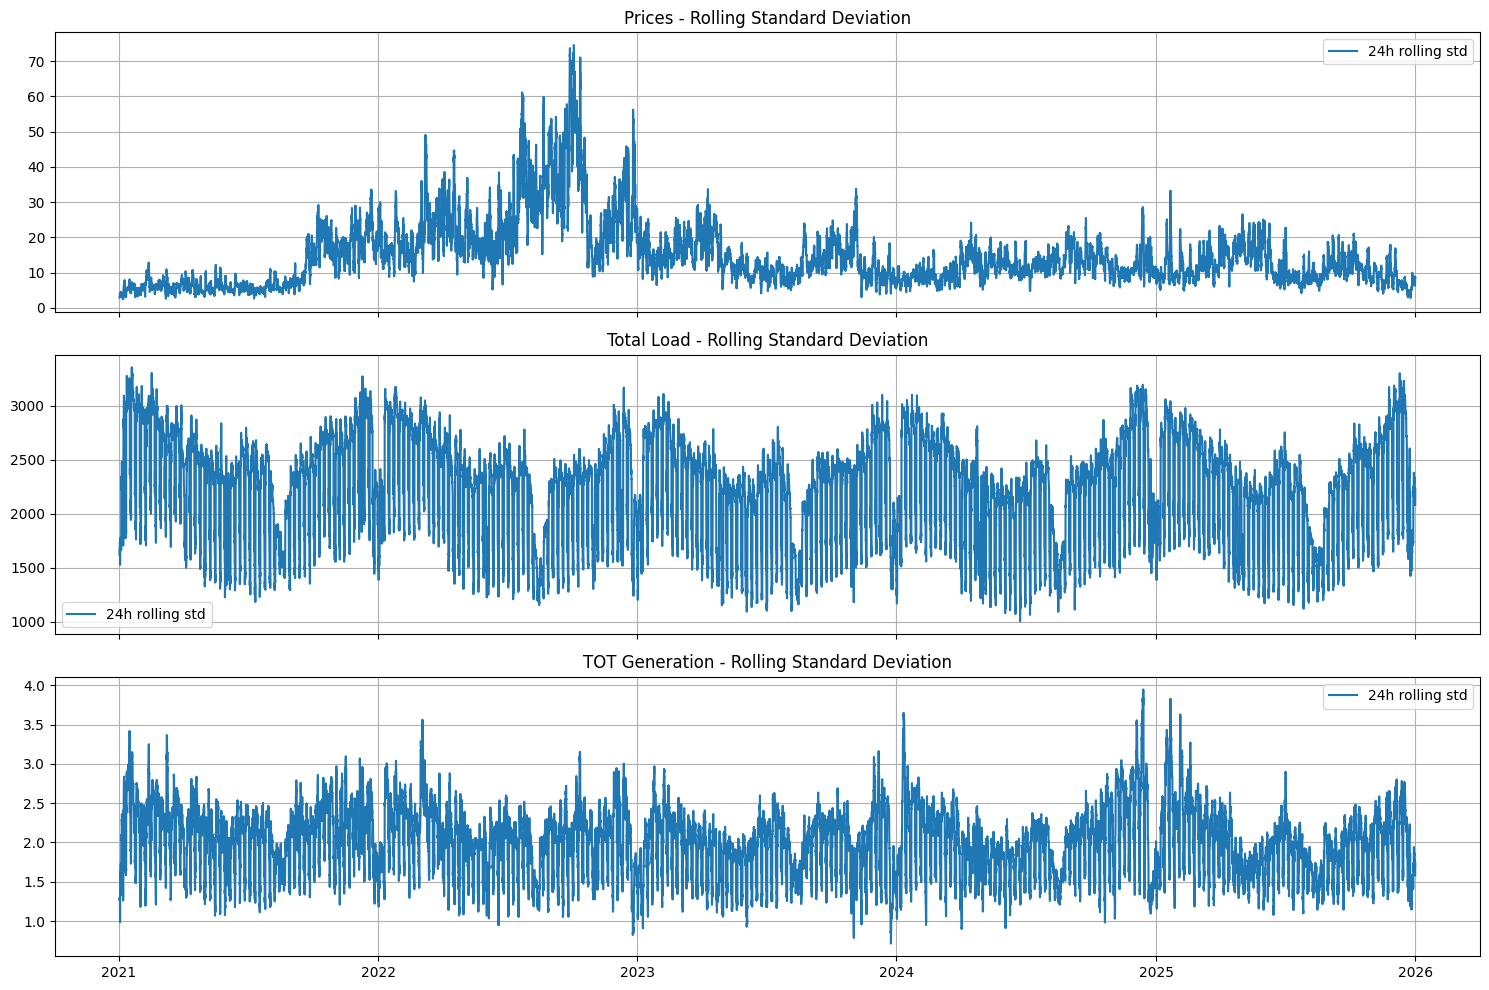

In [12]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col].diff().rolling(window).std(), label='24h rolling std')
    ax[i].set_title(f'{col} - Rolling Standard Deviation')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

While **prices** graph showed a tendency of prices of being stabilized after the Russian-Ukranian war, volatility shows otherise. As a matter of fact prices variations during the day became more promiment. Despite an apparently stabilization of prices after the Russian invasion, the volatility increased, which is consistent with:
* the expansion of renewables in the Italian power mix generation after the energy shock caused by the high dependecy from Russian gas imports;
* the increasing goepolitical risks associated with Middle East tensions.

**Generation** and **Load** have instead a similar pattern to the rolling mean graphs, which is explainadble by less volatility bounded by notable physical constraints.


#### 4.3.4. Intraday preview

Intraday pattern shows a so-called "duck-shaped" curve, which is the reason of so discussed introduction of batteries as power storage and producer so that the curves could be smoothened, and so, volatility reduced.

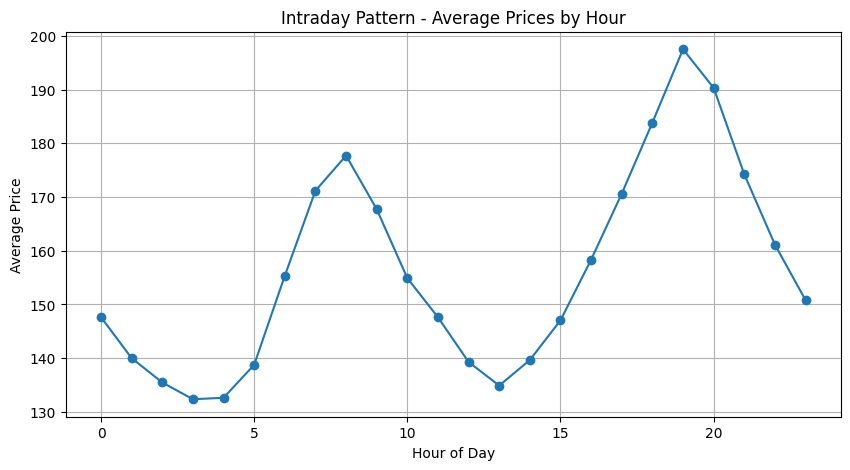

In [13]:
# select hours
data['hour'] = data['Date'].dt.hour

# group hours and calculate average prices
hourly_pattern = data.groupby('hour')['Prices'].mean()

# display graph
plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Intraday Pattern - Average Prices by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

### 4.4. Relationship analysis
Supply-demand interaction is crucial for determining the power spot markets prices determination.

#### 4.4.1. Correlation matrix

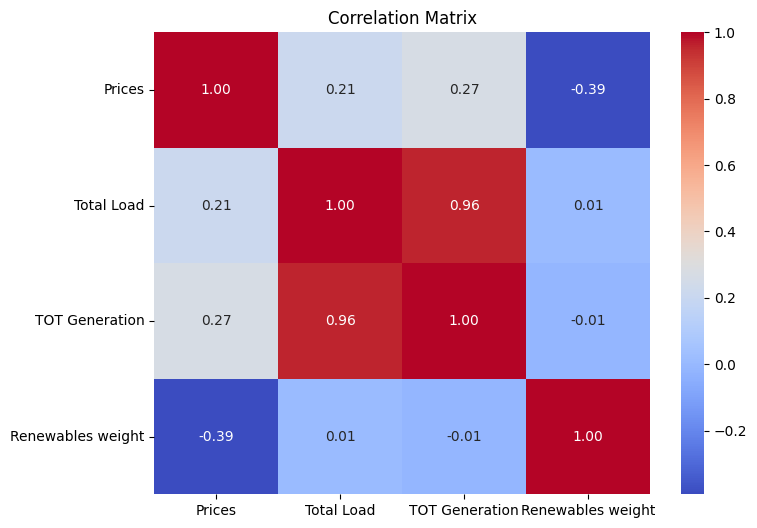

In [14]:
# inmport libraries
import matplotlib.pyplot as plt
import seaborn as sns

# select columns of interest
cols = [
    'Prices',
    'Total Load',
    'TOT Generation',
    'Renewables weight'
]

# correlation matrix
corr_matrix = data[cols].corr()

# display heated matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

Introducing **Renewables share** in Italian generation mix, negative correlation (-0.39) with prices is evident, confirming higher renewable penetration is associated with lower electricity prices, consistent with merit-order effect.  
The relation between Renewables and Load being near to 0 indicates largely indipendence between the two variables, while 0.13 with Generation, indicates a structural mismatch between consumption and generation profiles.

Generation (**Supply**) and Load (proxy for **Demand**) are positively correlated by 29%, indicating partial coupling between demand and production, mediated by imports and market structure.

#### 4.4.2. Scatterplots

A. Prices drivers
* Prices vs Total Load
* Prices vs TOT Generation
* Prices vs Renewables weight

B. Supply structure
* Total Load vs TOT Generation
* Total Load vs Renewables weight
* TOT Generation vs Renewables weight

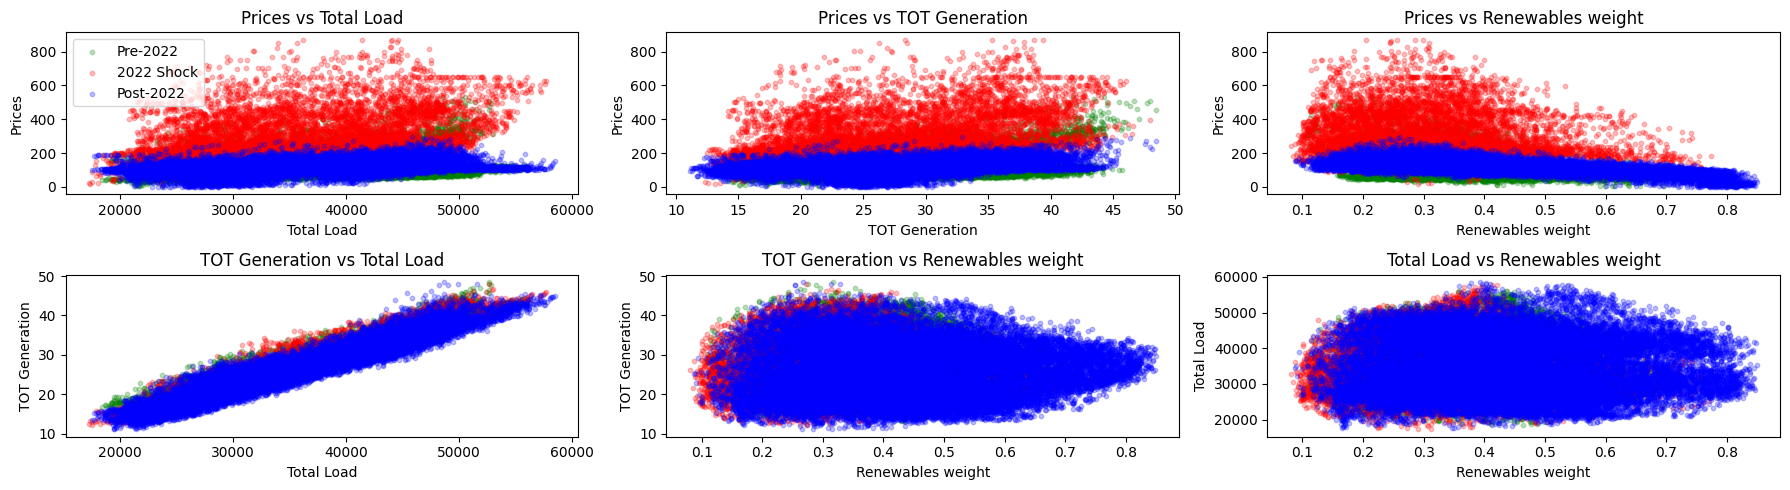

In [15]:
# import lkibraries
import numpy as np
import matplotlib.pyplot as plt

# define market regimes
data['Regime'] = np.where(data['Date'] < '2022-01-01', 'Pre-2022',
                   np.where(data['Date'] < '2023-01-01', '2022 Shock', 'Post-2022'))

# define pair of variables to compare
scatter_pairs = [
    ('Total Load', 'Prices'),
    ('TOT Generation', 'Prices'),
    ('Renewables weight', 'Prices'),
    ('Total Load', 'TOT Generation'),
    ('Renewables weight', 'TOT Generation'),
    ('Renewables weight', 'Total Load')
]

# define colors for each market regime
colors = {
    'Pre-2022': 'green',
    '2022 Shock': 'red',
    'Post-2022': 'blue'
}

# display graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (x, y) in enumerate(scatter_pairs):
    for regime, color in colors.items():
        subset = data[data['Regime'] == regime]
        axes[i].scatter(subset[x], subset[y],
                        alpha=0.25, s=10,
                        color=color,
                        label=regime)

    axes[i].set_title(f'{y} vs {x}')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

axes[0].legend()
plt.tight_layout()
plt.show()

To account for structural changes in the electricity market, the sample is divided into three distinct regimes: pre-2022, the 2022 shock period, and the post-2022 phase. This segmentation is motivated by the significant increase in price volatility observed during 2022, largely driven by the energy crisis and geopolitical tensions.

The scatterplots reveal that the relationship between prices and fundamental drivers such as load, generation, and renewable penetration is not stable over time. Instead, clear regime-dependent patterns emerge, with a visible structural break during 2022.

## Conclusions of the preliminary Exploratory data analysis

The exploratory analysis highlights a structurally segmented electricity market characterized by distinct pre- and post-2022 regimes. While demand remains relatively stable, prices exhibit high volatility and heavy-tailed distributions, suggesting strong exposure to external supply shocks.

The preliminary evidence also indicates that renewable penetration plays a relevant role in moderating price levels, motivating a dedicated analysis of its impact on price formation.